# 05 — Explainability: SHAP (Albania 2022)

Global and local explanations for the LightGBM model on the Albania 2022 cohort, trained on the **school-context** feature set (student features + survey-weighted school-mean ESCS/HOMEPOS/ANXMAT/TEACHSUP + cohort size — the additions that lifted AUC ~+0.05). LightGBM is fit fresh in this kernel — its Homebrew libomp is imported before scikit-learn (import-order fix), so the single-booster fit is OpenMP-safe and SHAP runs live.

## Methods & formulas (reference)

**SHAP (SHapley Additive exPlanations).** Attributes a prediction to features via
the game-theoretic **Shapley value** — the fair payout of feature $i$ averaged
over all orderings:
$$\phi_i=\!\!\sum_{S\subseteq F\setminus\{i\}}\!\!
\frac{|S|!\,(|F|-|S|-1)!}{|F|!}\,\big[f(S\cup\{i\})-f(S)\big].$$
They obey **local accuracy** (additivity): $f(x)=\phi_0+\sum_i\phi_i$, where the
base value $\phi_0=\mathbb{E}[f]$ — contributions plus base reconstruct the
prediction (here in log-odds). **TreeSHAP** computes them *exactly* for tree
ensembles in polynomial time.

**Global importance.** Mean absolute SHAP over the sample,
$\text{Imp}_i=\tfrac1n\sum_k|\phi_i^{(k)}|$ — the average magnitude of feature
$i$'s push on the prediction.

**Beeswarm / dependence.** Each dot is one student's $\phi_i$; a dependence plot
shows $\phi_i$ vs $x_i$ (coloured by an interacting feature) to reveal effect
direction and moderation. SHAP explains the **model** (associational), not
causation.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
try:
    import lightgbm  # noqa: F401 - load its Homebrew libomp BEFORE sklearn's (import-order fix, avoids rc=-11)
except Exception:
    pass
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import shap
from src.models.prepare import build_model_data, impute_median
from src.features.transformers import EngineeredFeatureBuilder
from src.models.registry import get_model
from src.explainability.shap_analysis import compute_shap_values, global_feature_importance

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math', add_school_context=True)
# engineered features (SES_COMPLETE, interactions, ...) built here for the
# final explanatory model (single fit on all data, so fit-on-all is fine)
X_eng = EngineeredFeatureBuilder().fit_transform(data.X)
(X,) = impute_median(X_eng); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape)

2026-07-03 11:39:41 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-03 11:39:41 [info     ] School aggregates added        cols=['ESCS', 'HOMEPOS', 'ANXMAT', 'TEACHSUP'] n_schools=274


2026-07-03 11:39:41 [info     ] Feature selection complete     n_features=18


2026-07-03 11:39:41 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=31 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


trained on (6129, 39)


## 1. Global feature importance (mean |SHAP|)

In [3]:
shap_vals, names = compute_shap_values(model, X,
        X_background=X.sample(min(300, len(X)), random_state=42), max_samples=2000)
imp = global_feature_importance(shap_vals, names)
imp

2026-07-03 11:39:42 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-07-03 11:39:42 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-07-03 11:39:42 [info     ] SHAP values computed           shape=(2000, 39)


,feature,mean_abs_shap,rank
0,SCH_MEAN_HOMEPOS,0.281138,1
1,ANXMAT,0.270674,2
2,SCH_MEAN_TEACHSUP,0.242234,3
3,SCH_MEAN_ESCS,0.229600,4
4,HISCED,0.206991,5
5,HOMEPOS,0.198854,6
6,SCH_N,0.197469,7
7,SCH_MEAN_ANXMAT,0.177324,8
8,BELONG,0.156456,9
9,MATERIAL_DEFICIT,0.144264,10


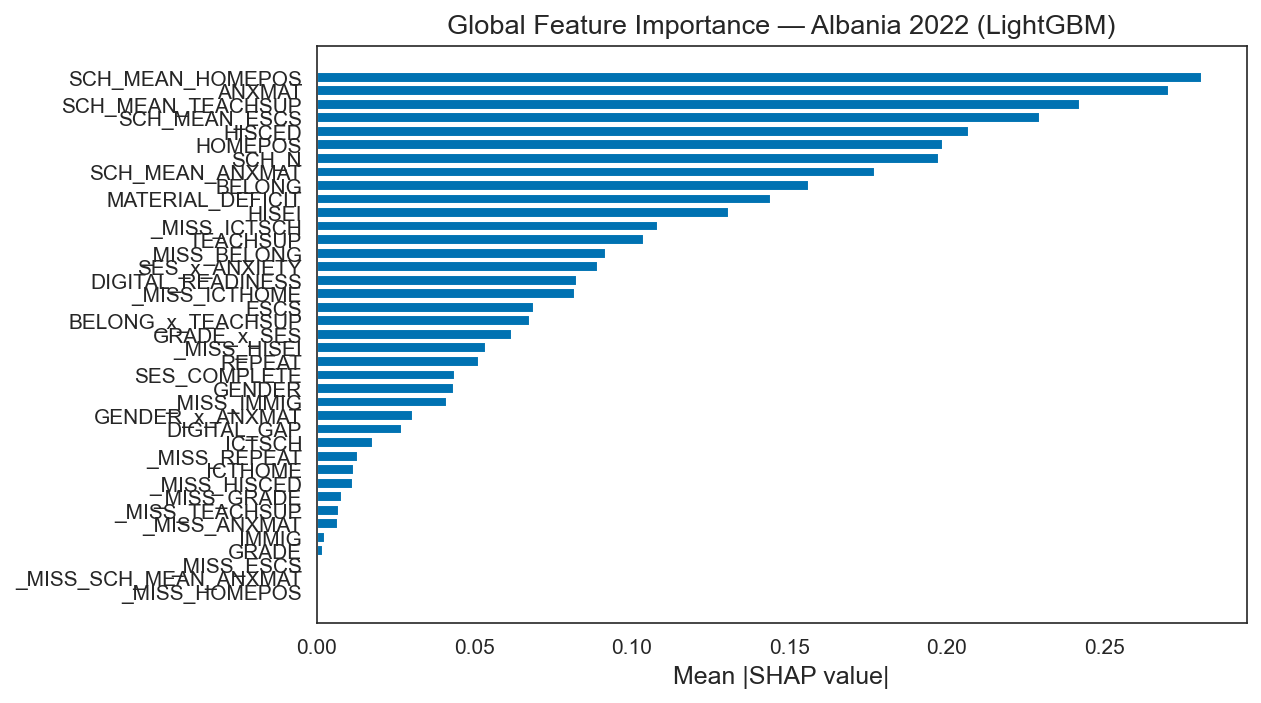

In [4]:
from src.visualization.style import apply_publication_style
apply_publication_style()
imp_s = imp.sort_values('mean_abs_shap')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_s['feature'], imp_s['mean_abs_shap'], color='#0072B2')
ax.set_xlabel('Mean |SHAP value|'); ax.set_title('Global Feature Importance — Albania 2022 (LightGBM)')
plt.show()

**Reading:** the top drivers are now dominated by **school-level context** — `SCH_MEAN_HOMEPOS` (school mean home possessions) is #1, with `SCH_MEAN_TEACHSUP`, `SCH_MEAN_ESCS` and `SCH_N` (cohort size) all in the top 7. The strongest *individual* factor is `ANXMAT` (math anxiety, #2), then `HISCED`/`HOMEPOS`. The model reads a student's risk more from the socioeconomic composition of their school than from their own resources — the compositional effect made explicit. Immigration and grade deviation still contribute almost nothing.

## 2. SHAP beeswarm — direction of effects

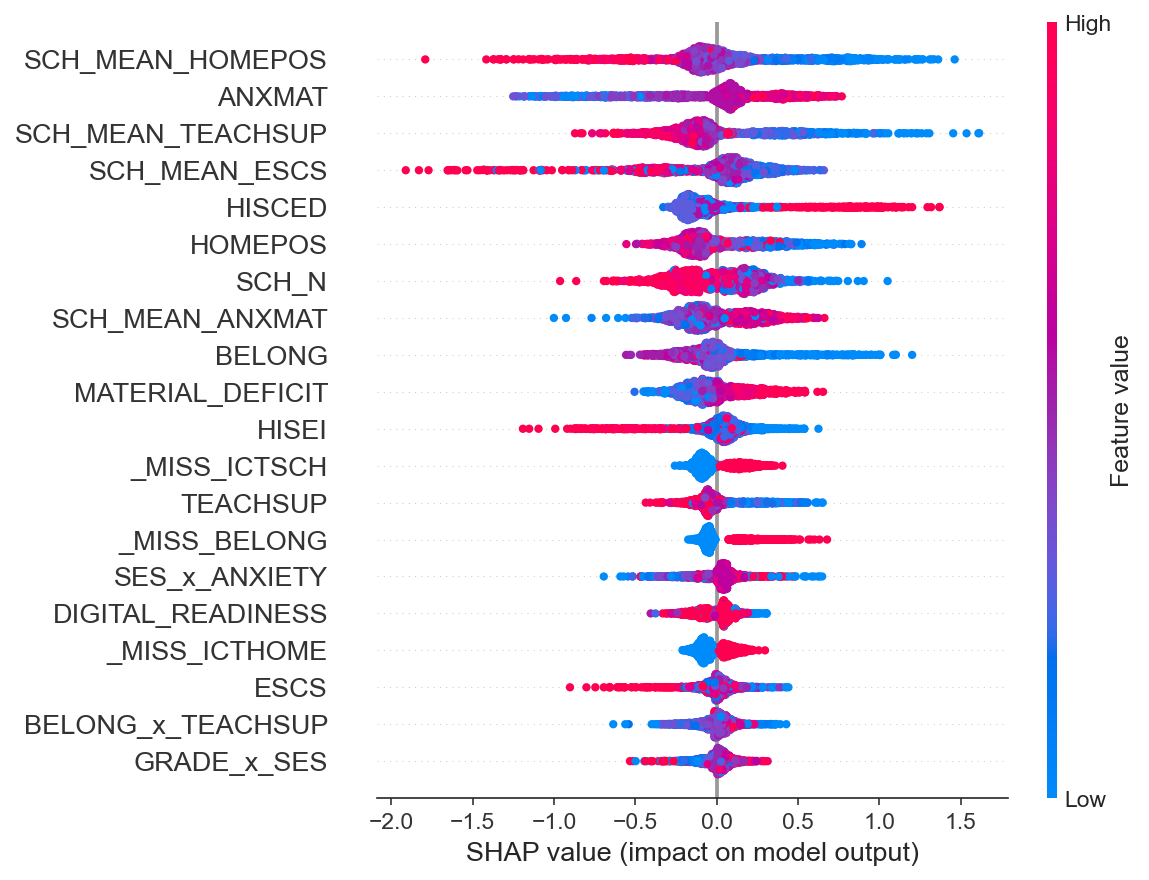

In [5]:
X_s = X.sample(min(2000, len(X)), random_state=42).reset_index(drop=True)
shap.summary_plot(shap_vals, X_s[names], show=True, plot_size=(8,6))

## 3. SHAP dependence — does SES moderate math anxiety?

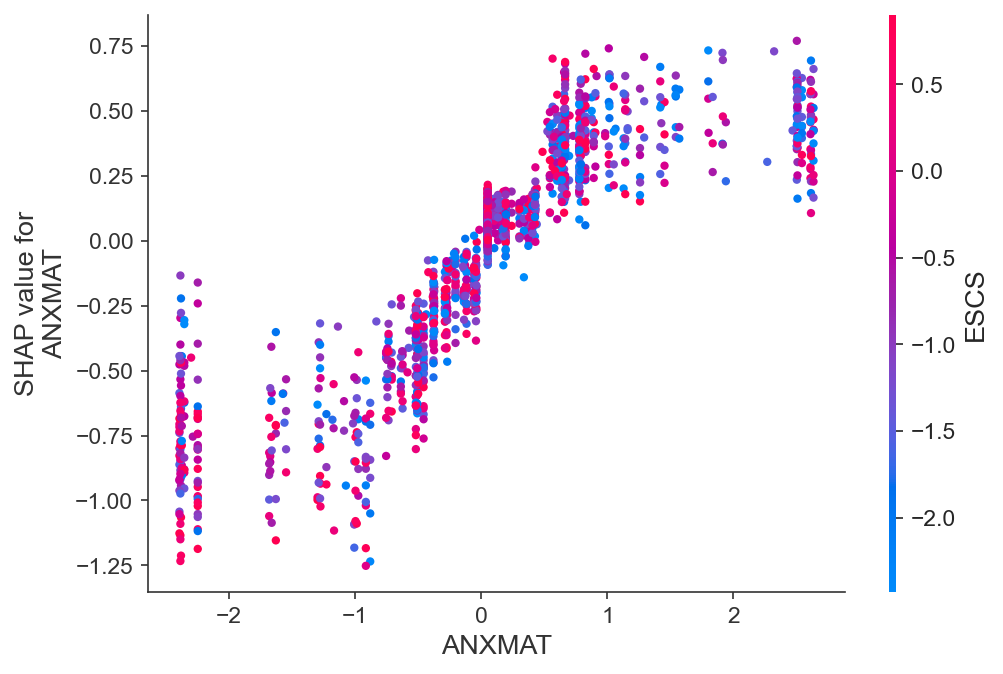

In [6]:
if 'ANXMAT' in names and 'ESCS' in names:
    shap.dependence_plot('ANXMAT', shap_vals, X_s[names], interaction_index='ESCS', show=True)

**Interpretation:** higher math anxiety pushes predictions toward at-risk; the colouring shows whether socioeconomic status buffers or amplifies that effect — a policy-relevant interaction.

## Conclusions & Interpretation

- **School composition dominates (mean |SHAP|):** `SCH_MEAN_HOMEPOS` > `ANXMAT` > `SCH_MEAN_TEACHSUP` > `SCH_MEAN_ESCS` > `HISCED` > `HOMEPOS` > `SCH_N`. Four of the top seven are school-level — the model reads risk more from the *school's* aggregate resources and support than from the student's own.
- **Top individual factor:** `ANXMAT` (math anxiety) is the strongest student-level driver, followed by parental education / home resources (`HISCED`, `HOMEPOS`).
- **Negligible:** immigration status and grade deviation add almost nothing — Albania's risk is a school-context-and-affect story, not a migration one.
- **Policy read:** the highest-leverage levers are *structural* — the socioeconomic segregation of schools and school-level teacher support — alongside individual math anxiety. A pure individual-student intervention misses the dominant, compositional signal. SHAP explains the *model* — associational, not causal.
- **Equity caveat:** because school-mean SES is now a top feature, the model partly encodes *where* a student goes to school; this is exactly the mechanism the fairness audit (notebook 07) probes for the SES gap.
- **Caveat:** explanations are for the single all-data LightGBM fit; per-fold stability and per-country SHAP comparison come in Phase 8.